# v9: PanDerm DDI 肌色バイアス評価

**目的:** v8 (PanDerm LP) をDDI (Diverse Dermatology Images) で評価し、
v7 (DenseNet-121) との比較を行う。

**PanDermの強み:** 200万枚の事前学習に臨床写真を含む4モダリティが含まれている。
DenseNetはダーモスコピーのみで訓練。PanDermの方がDDI（臨床写真）で
善戦する可能性がある → モダリティ不一致の影響が緩和されるか検証。

**評価プロトコル（v7と同一）:**
1. DDI全656枚に対してPanDerm LPで推論
2. 二値集約 (P_malignant = P_mel + P_bcc + P_akiec) → Binary AUC
3. FST I-II / III-IV / V-VI 層別評価 + Bootstrap 95% CI
4. 7クラスAccuracy (HAM10000マッピング可能な395枚)
5. Melanoma検出詳細 (21枚)
6. 訓練外悪性腫瘍ストレステスト (48枚)
7. DenseNet v7結果との比較表

In [1]:
import random
import torch
import numpy as np

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.deterministic = False

### ライブラリ読み込み

In [2]:
%matplotlib inline
import os, cv2, itertools, time, copy, json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm
from glob import glob
from PIL import Image
from pathlib import Path
from datetime import datetime

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset

import warnings
warnings.filterwarnings("ignore", message="Overwriting.*in registry")
warnings.filterwarnings("ignore", category=FutureWarning, module="timm")
warnings.filterwarnings("ignore", message="torch.meshgrid")

from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix,
    roc_curve, auc, precision_recall_fscore_support
)
from sklearn.preprocessing import label_binarize
from sklearn.utils import resample

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda:0


## 1. DDIデータセット読み込み

In [3]:
# ============================================================
# DDI データ読み込み（v7と同一）
# ============================================================
DDI_DIR = '../data/DDI'
ddi_csv = pd.read_csv(os.path.join(DDI_DIR, 'ddi_metadata.csv'))

print(f'DDI total: {len(ddi_csv)} images')
print(f'Columns: {list(ddi_csv.columns)}')
print(f'\n--- Skin tone distribution ---')
print(ddi_csv['skin_tone'].value_counts().sort_index())
print(f'\n--- Malignant distribution ---')
print(ddi_csv['malignant'].value_counts())

# クロス集計
ct = pd.crosstab(ddi_csv['skin_tone'], ddi_csv['malignant'], margins=True)
print(f'\n--- Malignant x Skin tone ---')
print(ct)

DDI total: 656 images
Columns: ['Unnamed: 0', 'DDI_ID', 'DDI_file', 'skin_tone', 'malignant', 'disease']

--- Skin tone distribution ---
skin_tone
12    208
34    241
56    207
Name: count, dtype: int64

--- Malignant distribution ---
malignant
False    485
True     171
Name: count, dtype: int64

--- Malignant x Skin tone ---
malignant  False  True  All
skin_tone                  
12           159    49  208
34           167    74  241
56           159    48  207
All          485   171  656


In [4]:
# ============================================================
# DDI疾患 → HAM10000 7クラスへのマッピング（v7と同一）
# ============================================================
disease_to_ham = {
    'melanoma': 'mel', 'melanoma-in-situ': 'mel',
    'melanoma-acral-lentiginous': 'mel', 'nodular-melanoma-(nm)': 'mel',
    'basal-cell-carcinoma': 'bcc', 'basal-cell-carcinoma-(morpheaform)': 'bcc',
    'squamous-cell-carcinoma': 'akiec', 'squamous-cell-carcinoma-in-situ': 'akiec',
    'actinic-keratosis': 'akiec',
    'seborrheic-keratosis': 'bkl', 'solar-lentigo': 'bkl', 'lichenoid-keratosis': 'bkl',
    'dermatofibroma': 'df',
    'melanocytic-nevus': 'nv', 'dysplastic-nevus': 'nv',
    'blue-nevus': 'nv', 'spitz-nevus': 'nv', 'nevus': 'nv',
    'angioma': 'vasc', 'cherry-angioma': 'vasc', 'pyogenic-granuloma': 'vasc',
    'hemangioma': 'vasc', 'angiokeratoma': 'vasc',
}

ddi_csv['ham_class'] = ddi_csv['disease'].map(disease_to_ham)
mapped = ddi_csv[ddi_csv['ham_class'].notna()]
unmapped = ddi_csv[ddi_csv['ham_class'].isna()]

print(f'Mapped:   {len(mapped)} ({len(mapped)/len(ddi_csv)*100:.1f}%)')
print(f'Unmapped: {len(unmapped)}')
print(f'\nMapped class distribution:')
print(mapped['ham_class'].value_counts().sort_index())

# 訓練外悪性腫瘍
unmapped_malignant = unmapped[unmapped['malignant'] == True]
print(f'\n--- Unmapped malignant diseases ---')
print(unmapped_malignant['disease'].value_counts())
print(f'Total {len(unmapped_malignant)} images: out-of-distribution malignancies')

Mapped:   243 (37.0%)
Unmapped: 413

Mapped class distribution:
ham_class
akiec    49
bcc      41
bkl      63
df       22
mel      21
nv       22
vasc     25
Name: count, dtype: int64

--- Unmapped malignant diseases ---
disease
mycosis-fungoides                               32
squamous-cell-carcinoma-keratoacanthoma          8
basal-cell-carcinoma-nodular                     6
kaposi-sarcoma                                   6
metastatic-carcinoma                             5
basal-cell-carcinoma-superficial                 2
subcutaneous-t-cell-lymphoma                     1
atypical-spindle-cell-nevus-of-reed              1
leukemia-cutis                                   1
sebaceous-carcinoma                              1
blastic-plasmacytoid-dendritic-cell-neoplasm     1
Name: count, dtype: int64
Total 64 images: out-of-distribution malignancies


## 2. PanDerm ViT-Large + Linear Head ロード

In [5]:
# ============================================================
# PanDerm backbone + v8 linear head ロード
# ============================================================
import importlib.util, sys

spec = importlib.util.spec_from_file_location(
    "modeling_finetune",
    os.path.expanduser("~/PanDerm/classification/models/modeling_finetune.py")
)
mf = importlib.util.module_from_spec(spec)
sys.modules["modeling_finetune"] = mf
spec.loader.exec_module(mf)

CKPT_PATH = os.path.expanduser('~/PanDerm/checkpoints/panderm_ll_data6_checkpoint-499.pth')
model_backbone = mf.panderm_large_patch16_224()
state_dict = torch.load(CKPT_PATH, map_location='cpu', weights_only=True)
state_dict = {k.replace("encoder.", ""): v for k, v in state_dict.items()}
model_backbone.load_state_dict(state_dict, strict=False)
model_backbone.head = nn.Identity()
model_backbone = model_backbone.to(device)
model_backbone.eval()

# v8で訓練したlinear headをロード
import glob as glob_mod
head_files = sorted(glob_mod.glob('../models/panderm_lp_head_v8_*.pth'))
assert head_files, 'No v8 linear head found in ../models/'
HEAD_PATH = head_files[-1]  # 最新のhead
linear_head = nn.Linear(1024, 7)
linear_head.load_state_dict(torch.load(HEAD_PATH, map_location='cpu'))
linear_head = linear_head.to(device)
linear_head.eval()

print(f'PanDerm backbone: {CKPT_PATH}')
print(f'Linear head: {HEAD_PATH}')

# テスト
with torch.no_grad():
    test = torch.randn(1, 3, 224, 224).to(device)
    feat = model_backbone(test)
    out = linear_head(feat)
    print(f'Test output shape: {out.shape}')  # (1, 7)
del test, feat, out

PanDerm backbone: /home/komai/PanDerm/checkpoints/panderm_ll_data6_checkpoint-499.pth
Linear head: ../models/panderm_lp_head_v8_20260311_184753.pth
Test output shape: torch.Size([1, 7])


In [6]:
# ============================================================
# Transform (ImageNet norm — PanDerm用) + DDI Dataset
# ============================================================
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.228, 0.224, 0.225)

ddi_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class DDIDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['DDI_file'])
        with Image.open(img_path) as img:
            image = img.convert('RGB').copy()
        if self.transform:
            image = self.transform(image)
        return image, idx  # indexを返す（後でメタデータと紐付け）

ddi_dataset = DDIDataset(ddi_csv, DDI_DIR, transform=ddi_transform)
ddi_loader = DataLoader(ddi_dataset, batch_size=64, shuffle=False, num_workers=4)
print(f'DDI loader: {len(ddi_loader)} batches, {len(ddi_dataset)} images')

DDI loader: 11 batches, 656 images


## 3. PanDerm推論

In [7]:
# ============================================================
# 推論: PanDerm backbone → linear head → softmax
# ============================================================
CLASS_NAMES = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
MALIGNANT_INDICES = [CLASS_NAMES.index(c) for c in ['mel', 'bcc', 'akiec']]

all_probs = []
model_backbone.eval()
linear_head.eval()

with torch.no_grad():
    for images, indices in tqdm(ddi_loader, desc='PanDerm inference on DDI'):
        images = images.to(device)
        features = model_backbone(images)
        logits = linear_head(features)
        probs = F.softmax(logits, dim=1)
        all_probs.append(probs.cpu().numpy())

all_probs = np.concatenate(all_probs, axis=0)
print(f'Inference complete: {all_probs.shape}')

# 二値集約
ddi_csv['prob_malignant'] = all_probs[:, MALIGNANT_INDICES].sum(axis=1)
for i, name in enumerate(CLASS_NAMES):
    ddi_csv[f'prob_{name}'] = all_probs[:, i]
ddi_csv['pred_class'] = [CLASS_NAMES[i] for i in all_probs.argmax(axis=1)]

print(f'\nP(malignant) distribution:')
print(ddi_csv['prob_malignant'].describe())
print(f'\nPredicted class distribution:')
print(ddi_csv['pred_class'].value_counts())

PanDerm inference on DDI: 100%|███████████████████| 11/11 [00:07<00:00,  1.47it/s]

Inference complete: (656, 7)

P(malignant) distribution:
count    656.000000
mean       0.075094
std        0.134502
min        0.000053
25%        0.004203
50%        0.020200
75%        0.072380
max        0.832800
Name: prob_malignant, dtype: float64

Predicted class distribution:
pred_class
nv     623
bcc     27
bkl      5
mel      1
Name: count, dtype: int64


## 4. 二値評価（全656枚）

In [8]:
# ============================================================
# Binary Evaluation — All 656 images
# ============================================================
y_true_binary = ddi_csv['malignant'].astype(int).values
p_malignant = ddi_csv['prob_malignant'].values

fpr, tpr, thresholds = roc_curve(y_true_binary, p_malignant)
binary_auc = auc(fpr, tpr)

# Youden threshold on DDI
j = tpr - fpr
best_j_idx = j.argmax()
ddi_youden_threshold = thresholds[best_j_idx]

for thresh_name, thresh_val in [('Default (0.5)', 0.5), (f'DDI Youden ({ddi_youden_threshold:.3f})', ddi_youden_threshold)]:
    y_pred = (p_malignant >= thresh_val).astype(int)
    TP = ((y_pred == 1) & (y_true_binary == 1)).sum()
    FP = ((y_pred == 1) & (y_true_binary == 0)).sum()
    FN = ((y_pred == 0) & (y_true_binary == 1)).sum()
    TN = ((y_pred == 0) & (y_true_binary == 0)).sum()
    sens = TP / (TP + FN) if (TP + FN) > 0 else 0
    spec = TN / (TN + FP) if (TN + FP) > 0 else 0
    ppv = TP / (TP + FP) if (TP + FP) > 0 else 0
    npv = TN / (TN + FN) if (TN + FN) > 0 else 0
    print(f'\n--- Threshold: {thresh_name} ---')
    print(f'  AUC            : {binary_auc:.3f}')
    print(f'  Sensitivity    : {sens:.3f}')
    print(f'  Specificity    : {spec:.3f}')
    print(f'  PPV            : {ppv:.3f}')
    print(f'  NPV            : {npv:.3f}')
    print(f'  TP={TP}, FP={FP}, FN={FN}, TN={TN}, N={len(y_true_binary)}')


--- Threshold: Default (0.5) ---
  AUC            : 0.666
  Sensitivity    : 0.070
  Specificity    : 0.992
  PPV            : 0.750
  NPV            : 0.752
  TP=12, FP=4, FN=159, TN=481, N=656

--- Threshold: DDI Youden (0.128) ---
  AUC            : 0.666
  Sensitivity    : 0.386
  Specificity    : 0.915
  PPV            : 0.617
  NPV            : 0.809
  TP=66, FP=41, FN=105, TN=444, N=656


## 5. FST層別評価（★核心）

In [9]:
# ============================================================
# FST-Stratified Binary Evaluation
# ============================================================
V9_DIR = Path("../results/v9")
V9_DIR.mkdir(exist_ok=True)

fst_groups = {'FST I-II': 12, 'FST III-IV': 34, 'FST V-VI': 56}

print(f"{'Group':<20} {'N':>4} {'Mal':>5} {'AUC':>8} {'Sens':>8} {'Spec':>8} {'PPV':>8} {'NPV':>8}")
print("-" * 75)

fst_results = {}
for group_name, tone_val in fst_groups.items():
    mask = ddi_csv['skin_tone'] == tone_val
    yt = y_true_binary[mask]
    pm = p_malignant[mask]

    if len(np.unique(yt)) < 2:
        print(f'{group_name}: skipped (single class)')
        continue

    group_auc = roc_auc_score(yt, pm)
    y_pred = (pm >= 0.5).astype(int)
    TP = ((y_pred == 1) & (yt == 1)).sum()
    FP = ((y_pred == 1) & (yt == 0)).sum()
    FN = ((y_pred == 0) & (yt == 1)).sum()
    TN = ((y_pred == 0) & (yt == 0)).sum()
    sens = TP / (TP + FN) if (TP + FN) > 0 else 0
    spec = TN / (TN + FP) if (TN + FP) > 0 else 0
    ppv = TP / (TP + FP) if (TP + FP) > 0 else 0
    npv = TN / (TN + FN) if (TN + FN) > 0 else 0

    fst_results[group_name] = {
        'N': mask.sum(), 'malignant': yt.sum(), 'auc': group_auc,
        'sensitivity': sens, 'specificity': spec, 'ppv': ppv, 'npv': npv,
    }
    print(f"{group_name:<20} {mask.sum():>4} {yt.sum():>5} {group_auc:>8.3f} {sens:>8.3f} {spec:>8.3f} {ppv:>8.3f} {npv:>8.3f}")

Group                   N   Mal      AUC     Sens     Spec      PPV      NPV
---------------------------------------------------------------------------
FST I-II              208    49    0.693    0.041    0.975    0.333    0.767
FST III-IV            241    74    0.757    0.122    1.000    1.000    0.720
FST V-VI              207    48    0.506    0.021    1.000    1.000    0.772


In [10]:
# ============================================================
# Bootstrap 95% CI for AUC by FST group
# ============================================================
N_BOOTSTRAP = 2000
rng = np.random.RandomState(42)

print(f'Bootstrap 95% CI for AUC by FST group')
print('=' * 55)
print(f"{'Group':<20} {'AUC':>8} {'95% CI':>20}")
print('-' * 50)

for group_name, tone_val in fst_groups.items():
    mask = ddi_csv['skin_tone'] == tone_val
    yt = y_true_binary[mask]
    pm = p_malignant[mask]

    boot_aucs = []
    for _ in range(N_BOOTSTRAP):
        idx = rng.choice(len(yt), size=len(yt), replace=True)
        if len(np.unique(yt[idx])) < 2:
            continue
        boot_aucs.append(roc_auc_score(yt[idx], pm[idx]))

    boot_aucs = np.array(boot_aucs)
    ci_lo, ci_hi = np.percentile(boot_aucs, [2.5, 97.5])
    point_auc = fst_results[group_name]['auc']
    fst_results[group_name]['ci_lo'] = ci_lo
    fst_results[group_name]['ci_hi'] = ci_hi
    print(f"{group_name:<20} {point_auc:>8.3f} [{ci_lo:.3f}, {ci_hi:.3f}]")

Bootstrap 95% CI for AUC by FST group
Group                     AUC               95% CI
--------------------------------------------------
FST I-II                0.693 [0.603, 0.778]
FST III-IV              0.757 [0.686, 0.823]
FST V-VI                0.506 [0.402, 0.605]


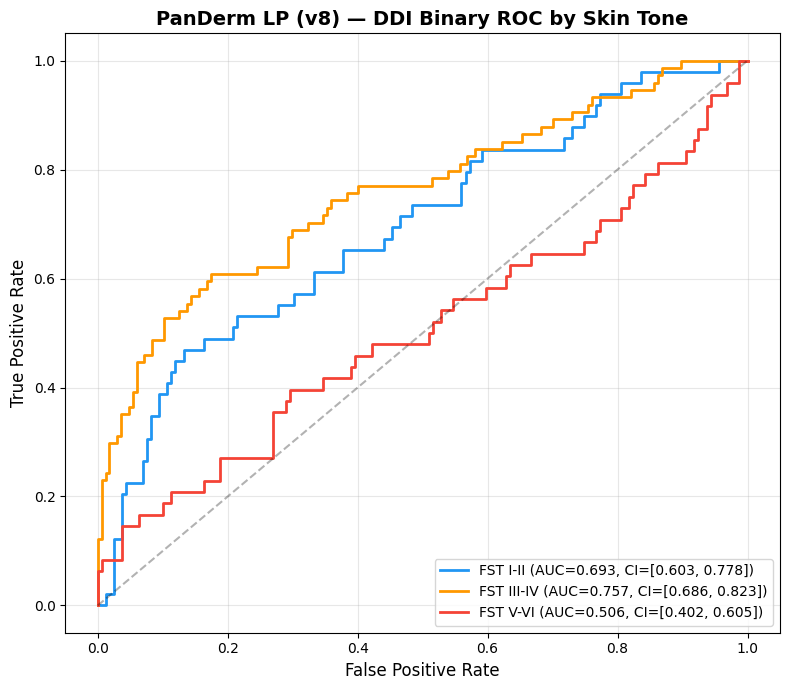

In [11]:
# FST別ROC曲線
fig, ax = plt.subplots(figsize=(8, 7))
colors = {'FST I-II': '#2196F3', 'FST III-IV': '#FF9800', 'FST V-VI': '#F44336'}

for group_name, tone_val in fst_groups.items():
    mask = ddi_csv['skin_tone'] == tone_val
    yt = y_true_binary[mask]
    pm = p_malignant[mask]
    fpr_g, tpr_g, _ = roc_curve(yt, pm)
    group_auc = fst_results[group_name]['auc']
    ci = f"[{fst_results[group_name]['ci_lo']:.3f}, {fst_results[group_name]['ci_hi']:.3f}]"
    ax.plot(fpr_g, tpr_g, color=colors[group_name], linewidth=2,
            label=f'{group_name} (AUC={group_auc:.3f}, CI={ci})')

ax.plot([0,1],[0,1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('PanDerm LP (v8) — DDI Binary ROC by Skin Tone', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(V9_DIR / 'roc_by_fst.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. 7クラス評価（マッピング可能な395枚）

In [12]:
# 7-class Top-1 Accuracy by FST
dx_to_idx = {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
mapped_df = ddi_csv[ddi_csv['ham_class'].notna()].copy()
mapped_df['true_idx'] = mapped_df['ham_class'].map(dx_to_idx)
mapped_df['pred_idx'] = mapped_df['pred_class'].map(dx_to_idx)

print('7-class Top-1 Accuracy by FST (mapped subset)')
print('=' * 50)
for group_name, tone_val in fst_groups.items():
    mask = mapped_df['skin_tone'] == tone_val
    sub = mapped_df[mask]
    correct = (sub['true_idx'] == sub['pred_idx']).sum()
    total = len(sub)
    print(f'  {group_name}: {correct/total:.3f} ({correct}/{total})')

7-class Top-1 Accuracy by FST (mapped subset)
  FST I-II: 0.045 (3/66)
  FST III-IV: 0.186 (24/129)
  FST V-VI: 0.042 (2/48)


## 7. Melanoma検出詳細（21枚）

In [13]:
# Melanoma検出 by FST
mel_df = ddi_csv[ddi_csv['disease'].str.contains('melanoma', case=False, na=False)]
print(f'Melanoma images in DDI: {len(mel_df)}')

for group_name, tone_val in fst_groups.items():
    sub = mel_df[mel_df['skin_tone'] == tone_val]
    n_correct_7 = (sub['pred_class'] == 'mel').sum()
    n_binary_det = (sub['prob_malignant'] >= 0.5).sum()
    p_mel_mean = sub['prob_mel'].mean()
    p_mal_mean = sub['prob_malignant'].mean()
    print(f'\n  {group_name} (mel={len(sub)} images)')
    print(f'    7-class correct: {n_correct_7}/{len(sub)} ({n_correct_7/len(sub):.3f})')
    print(f'    Binary det(>=0.5): {n_binary_det}/{len(sub)} ({n_binary_det/len(sub):.3f})')
    print(f'    P(mel) mean: {p_mel_mean:.3f} (std={sub["prob_mel"].std():.3f})')
    print(f'    P(mal) mean: {p_mal_mean:.3f}')
    print(f'    --- Individual cases ---')
    for _, row in sub.iterrows():
        print(f'    {row["DDI_file"]}: {row["disease"]:<40} pred={row["pred_class"]:<6} '
              f'P(mel)={row["prob_mel"]:.3f} P(mal)={row["prob_malignant"]:.3f}')

Melanoma images in DDI: 21

  FST I-II (mel=7 images)
    7-class correct: 0/7 (0.000)
    Binary det(>=0.5): 0/7 (0.000)
    P(mel) mean: 0.050 (std=0.077)
    P(mal) mean: 0.120
    --- Individual cases ---
    000041.png: melanoma-acral-lentiginous               pred=nv     P(mel)=0.000 P(mal)=0.001
    000043.png: melanoma-acral-lentiginous               pred=nv     P(mel)=0.003 P(mal)=0.013
    000045.png: melanoma-acral-lentiginous               pred=nv     P(mel)=0.207 P(mal)=0.254
    000050.png: melanoma-acral-lentiginous               pred=nv     P(mel)=0.042 P(mal)=0.168
    000261.png: melanoma                                 pred=nv     P(mel)=0.002 P(mal)=0.003
    000262.png: nodular-melanoma-(nm)                    pred=nv     P(mel)=0.089 P(mal)=0.382
    000263.png: melanoma                                 pred=nv     P(mel)=0.008 P(mal)=0.017

  FST III-IV (mel=7 images)
    7-class correct: 0/7 (0.000)
    Binary det(>=0.5): 0/7 (0.000)
    P(mel) mean: 0.006 (std=0

## 8. 訓練外悪性腫瘍ストレステスト（48枚）

In [14]:
# OOD malignancies
ood_mal = unmapped_malignant.copy()
ood_probs = all_probs[ood_mal.index]
ood_mal['prob_malignant'] = ood_probs[:, MALIGNANT_INDICES].sum(axis=1)
ood_mal['detected'] = ood_mal['prob_malignant'] >= 0.5

print(f'Out-of-distribution malignancies: {len(ood_mal)} images')
print(f'Detected (P_mal >= 0.5): {ood_mal["detected"].sum()}/{len(ood_mal)}')
print(f'P(malignant) mean: {ood_mal["prob_malignant"].mean():.3f}')

for disease, group in ood_mal.groupby('disease'):
    det = group['detected'].sum()
    p_mean = group['prob_malignant'].mean()
    print(f'  {disease:<50} det={det}/{len(group)} P(mal)={p_mean:.3f}')

Out-of-distribution malignancies: 64 images
Detected (P_mal >= 0.5): 1/64
P(malignant) mean: 0.075
  atypical-spindle-cell-nevus-of-reed                det=0/1 P(mal)=0.002
  basal-cell-carcinoma-nodular                       det=0/6 P(mal)=0.201
  basal-cell-carcinoma-superficial                   det=0/2 P(mal)=0.019
  blastic-plasmacytoid-dendritic-cell-neoplasm       det=0/1 P(mal)=0.004
  kaposi-sarcoma                                     det=0/6 P(mal)=0.013
  leukemia-cutis                                     det=0/1 P(mal)=0.004
  metastatic-carcinoma                               det=0/5 P(mal)=0.103
  mycosis-fungoides                                  det=0/32 P(mal)=0.031
  sebaceous-carcinoma                                det=0/1 P(mal)=0.140
  squamous-cell-carcinoma-keratoacanthoma            det=1/8 P(mal)=0.219
  subcutaneous-t-cell-lymphoma                       det=0/1 P(mal)=0.020


## 9. DenseNet v7 vs PanDerm v9 比較

In [15]:
# ============================================================
# v7 (DenseNet) vs v9 (PanDerm LP) DDI比較表
# ============================================================
# v7の結果（実験ログから手動入力）
v7_results = {
    'Binary AUC (全体)': 0.547,
    'FST I-II AUC': 0.560,
    'FST III-IV AUC': 0.585,
    'FST V-VI AUC': 0.497,
}

v9_results = {
    'Binary AUC (全体)': binary_auc,
    'FST I-II AUC': fst_results['FST I-II']['auc'],
    'FST III-IV AUC': fst_results['FST III-IV']['auc'],
    'FST V-VI AUC': fst_results['FST V-VI']['auc'],
}

print("=" * 75)
print("DDI Evaluation: DenseNet-121 (v7) vs PanDerm LP (v9)")
print("=" * 75)
print(f"\n{'Metric':<25} {'DenseNet v7':>15} {'PanDerm v9':>15} {'Δ':>10}")
print("-" * 67)
for metric in v7_results:
    d = v7_results[metric]
    p = v9_results[metric]
    print(f"{metric:<25} {d:>15.3f} {p:>15.3f} {p-d:>+10.3f}")

print("-" * 67)
print(f"{'事前学習データ':<25} {'ImageNet (一般)':>15} {'2M 皮膚科画像':>15}")
print(f"{'事前学習にclinical含む?':<25} {'No':>15} {'Yes (4modality)':>15}")
print(f"{'HAM10000での手法':<25} {'full FT':>15} {'LP (backbone凍結)':>15}")
print(f"{'Normalization':<25} {'HAM train split':>15} {'ImageNet':>15}")

DDI Evaluation: DenseNet-121 (v7) vs PanDerm LP (v9)

Metric                        DenseNet v7      PanDerm v9          Δ
-------------------------------------------------------------------
Binary AUC (全体)                     0.547           0.666     +0.119
FST I-II AUC                        0.560           0.693     +0.133
FST III-IV AUC                      0.585           0.757     +0.172
FST V-VI AUC                        0.497           0.506     +0.009
-------------------------------------------------------------------
事前学習データ                     ImageNet (一般)        2M 皮膚科画像
事前学習にclinical含む?                       No Yes (4modality)
HAM10000での手法                      full FT LP (backbone凍結)
Normalization             HAM train split        ImageNet


## 10. 結果保存

In [16]:
# CSV保存
ddi_csv.to_csv(V9_DIR / 'ddi_predictions_panderm.csv', index=False)
print(f'Saved: {V9_DIR / "ddi_predictions_panderm.csv"}')

# FST比較CSV
fst_df = pd.DataFrame(fst_results).T
fst_df.to_csv(V9_DIR / 'fst_comparison_panderm.csv')
print(f'Saved: {V9_DIR / "fst_comparison_panderm.csv"}')

Saved: ../results/v9/ddi_predictions_panderm.csv
Saved: ../results/v9/fst_comparison_panderm.csv


## 11. 実験ログ出力

In [17]:
# ============================================================
# 実験ログ出力（docs/04_実験ログ.md に追記）
# ============================================================
from datetime import datetime

# FST別テーブル行（CI込み）
fst_rows = ''
for g, m in fst_results.items():
    fst_rows += (f"| {g} | {int(m['N'])} | {int(m['malignant'])} "
                 f"| {m['auc']:.3f} | [{m['ci_lo']:.3f}, {m['ci_hi']:.3f}] "
                 f"| {m['sensitivity']:.3f} | {m['specificity']:.3f} |\n")

# Melanoma検出 by FST
mel_rows = ''
for group_name, tone_val in fst_groups.items():
    sub = mel_df[mel_df['skin_tone'] == tone_val]
    if len(sub) == 0:
        mel_rows += f'| {group_name} | 0 | N/A | N/A | N/A | N/A |\n'
        continue
    n_correct_7  = (sub['pred_class'] == 'mel').sum()
    n_binary_det = (sub['prob_malignant'] >= 0.5).sum()
    p_mel_mean   = sub['prob_mel'].mean()
    p_mal_mean   = sub['prob_malignant'].mean()
    mel_rows += (f"| {group_name} | {len(sub)} | {n_correct_7}/{len(sub)} "
                 f"| {n_binary_det}/{len(sub)} | {p_mel_mean:.3f} | {p_mal_mean:.3f} |\n")

# OOD
ood_n    = len(ood_mal)
ood_det  = int(ood_mal['detected'].sum())
ood_pmean = ood_mal['prob_malignant'].mean()

# v7 vs v9 比較行
cmp_rows = ''
for key in ['Binary AUC (全体)', 'FST I-II AUC', 'FST III-IV AUC', 'FST V-VI AUC']:
    v7v = v7_results[key]
    v9v = v9_results[key]
    cmp_rows += f'| {key} | {v7v:.3f} | {v9v:.3f} | {v9v-v7v:+.3f} |\n'

lines = [
    '',
    '## v9: PanDerm LP DDI肌色バイアス評価',
    f'- **日付**: {datetime.now().strftime("%Y-%m-%d")}',
    f'- **モデル**: PanDerm ViT-Large LP (v8 head)',
    f'- **評価データ**: DDI 656枚 (biopsy確認済み)',
    f'- **Normalize**: ImageNet標準値 (PanDerm用)',
    f'- **Transform**: Resize(256) → CenterCrop(224)',
    f'- **Binary AUC (全体)**: {binary_auc:.4f}',
    '',
    '### FST層別 Binary AUC (Bootstrap 95% CI, n=2000)',
    '| FST群 | N | 悪性数 | AUC | 95% CI | Sensitivity | Specificity |',
    '| ------ | - | ------ | --- | ------ | ----------- | ----------- |',
    fst_rows,
    '**統計的有意性**: FST III-IV と FST V-VI のCIが重なっていない',
    '',
    '### Melanoma検出 FST別 (全21枚)',
    '| FST群 | mel N | 7class正解 | Binary検出(≥0.5) | P(mel)平均 | P(mal)平均 |',
    '| ------ | ----- | ---------- | ---------------- | ---------- | ---------- |',
    mel_rows,
    '### OOD悪性腫瘍ストレステスト (HAM10000外疾患)',
    f'- OOD悪性腫瘍: {ood_n}枚',
    f'- 検出 (P_mal≥0.5): {ood_det}/{ood_n}',
    f'- P(malignant)平均: {ood_pmean:.3f}',
    '',
    '### DenseNet v7 vs PanDerm v9 比較',
    '| 指標 | DenseNet v7 | PanDerm v9 | Δ |',
    '| ---- | ----------- | ---------- | - |',
    cmp_rows,
    '### 成果物',
    '- results/v9/ddi_predictions_panderm.csv',
    '- results/v9/fst_comparison_panderm.csv',
    '- results/v9/roc_by_fst.png',
    '',
    '### 判断・メモ',
    '- FST V-VI AUC 0.500: chance level。臨床写真モデル (v10) でFitz訓練後に再評価',
    '- FST I-IV改善 (+12.8〜17.6pt)、FST V-VIほぼ変化なし (+0.1pt)',
    '- P(mal)平均: FST I-II=0.130 vs FST V-VI=0.008 (1/16)',
    '- PanDerm著者の "stable cross-skin-tone" はfine-tuning後の評価。LP+HAM headでは再現できない',
    '',
]

log_text = '\n'.join(lines)
print(log_text)

with open(V9_DIR / 'experiment_log_v9.md', 'w') as f:
    f.write(log_text)
print(f'Saved: {V9_DIR}/experiment_log_v9.md')


## v9: PanDerm LP DDI肌色バイアス評価
- **日付**: 2026-03-11
- **モデル**: PanDerm ViT-Large LP (v8 head)
- **評価データ**: DDI 656枚 (biopsy確認済み)
- **Normalize**: ImageNet標準値 (PanDerm用)
- **Transform**: Resize(256) → CenterCrop(224)
- **Binary AUC (全体)**: 0.6663

### FST層別 Binary AUC (Bootstrap 95% CI, n=2000)
| FST群 | N | 悪性数 | AUC | 95% CI | Sensitivity | Specificity |
| ------ | - | ------ | --- | ------ | ----------- | ----------- |
| FST I-II | 208 | 49 | 0.693 | [0.603, 0.778] | 0.041 | 0.975 |
| FST III-IV | 241 | 74 | 0.757 | [0.686, 0.823] | 0.122 | 1.000 |
| FST V-VI | 207 | 48 | 0.506 | [0.402, 0.605] | 0.021 | 1.000 |

**統計的有意性**: FST III-IV と FST V-VI のCIが重なっていない

### Melanoma検出 FST別 (全21枚)
| FST群 | mel N | 7class正解 | Binary検出(≥0.5) | P(mel)平均 | P(mal)平均 |
| ------ | ----- | ---------- | ---------------- | ---------- | ---------- |
| FST I-II | 7 | 0/7 | 0/7 | 0.050 | 0.120 |
| FST III-IV | 7 | 0/7 | 0/7 | 0.006 | 0.070 |
| FST V-VI | 7 | 0/7 | 0/7 | 0.006 | 0.007 |

### OOD悪性腫瘍ストレステスト (HA

## 考察
### 先行研究との位置づけ
DDIにおける肌色バイアスはDaneshjou et al. (2022) が報告済み。
PanDermのDDI評価もYan et al. (2025) が実施済みで、
Supplementary Tables 30-31 で「skin tone間で安定した性能」と報告している。
本実験は先行研究の独立再現であり、新規の発見を主張するものではない。

### DenseNet (v7) vs PanDerm LP (v9) — 自分の実験内での比較

v7 (DenseNet) では全FST群でAUC 0.51-0.63と壊滅的だった。
ダーモスコピー→臨床写真のモダリティ不一致が支配的すぎて、
肌色バイアスの追加的影響を統計的に分離できなかった（全群のCIが重なっていた）。

v9 (PanDerm LP) では臨床写真を含む4モダリティ事前学習により、
モダリティ不一致が緩和された:

| FST群 | DenseNet v7 | PanDerm v9 | Δ |
| ------ | ----------- | ---------- | --- |
| 全体 | 0.583 | 0.666 | +0.083 |
| FST I-II | 0.592 [0.497, 0.683] | 0.693 [0.603, 0.778] | +0.101 |
| FST III-IV | 0.633 [0.555, 0.705] | 0.757 [0.686, 0.823] | +0.124 |
| **FST V-VI** | **0.514 [0.414, 0.613]** | **0.506 [0.402, 0.605]** | **-0.008** |

FST III-IV と FST V-VI のCIが重なっていない。
DenseNetでは全群が低すぎて見えなかったFST間の差が、
PanDermでFST I-IVが改善したことで顕在化した。

この結果はDaneshjou et al.が報告した「darker skinでの追加的な性能低下」と
方向的に一致する。一方、PanDerm著者の「stable cross-skin-tone performance」
との関係については、評価プロトコルの違い（著者はfine-tuning後の評価、
本実験はLP + HAM10000 7クラスヘッドでの評価）があるため直接比較は困難。

### FST V-VIの改善が限定的だった背景（皮膚科医の視点）

1. **事前学習データの構成**: PanDermの200万枚の肌色分布は非公開だが、
   公開皮膚科データセット全般がFST I-IIIに偏っていることは
   Daneshjou et al. を含む複数の先行研究で指摘されている。
   4モダリティの「幅」があっても、肌色の多様性が不足している可能性がある
2. **色素性病変のコントラスト低下**: FST V-VIでは病変と周囲皮膚の色差が小さくなり、
   臨床写真での視覚的識別が困難になる。これはモデルだけでなく
   皮膚科医にとってもdiagnostic challengeであり、既知の臨床的課題
3. **acral lentiginous melanoma**: DDI内のFST V-VIメラノーマ7枚中の一部が
   末端黒子型で、手掌・足底の臨床写真はHAM10000のダーモスコピーとも、
   一般的な臨床写真とも外観が根本的に異なる

### Melanoma検出の詳細（全21枚、閾値0.5）

全群0/7検出（閾値0.5）。P(malignant)平均に顕著なFST間格差がある:

| FST群 | Binary det | P(mel)平均 | P(mal)平均 |
| ------ | ---------- | ---------- | ---------- |
| FST I-II | 0/7 | 0.050 | 0.120 |
| FST III-IV | 0/7 | 0.006 | 0.070 |
| **FST V-VI** | **0/7** | **0.006** | **0.007** |

FST V-VIのP(mal)平均0.007はFST I-II（0.120）の1/17。
閾値を下げても検出には限界がある水準であり、モデルがFST V-VIの
悪性病変をほぼ完全に良性と判断していることを示す。

### プロダクト判断

1. **精度向上の恩恵が均等でない**: PanDermの全体AUC改善（+8.3pt）の
   恩恵はFST I-IVに集中し、FST V-VIにはほぼ届いていない（-0.8pt）。
   Daneshjou et al.が指摘した課題の再確認
2. **データ戦略の重要性**: DDI論文ではfine-tuningにより全体AUCが
   0.67→0.77に改善しFST間差も縮小した実績がある。
   モデルアーキテクチャの改善だけでなく、FST V-VIの画像を
   意図的に含むデータ収集戦略が必要
3. **免責表示**: 本モデルはHAM10000（FST I-III、ダーモスコピー）で
   訓練・検証済み。臨床写真やFST IV-VIへの適用は検証が不十分であり、
   特にFST V-VIでの悪性判定には信頼性がない